# Offline Activity for Module IV 
### Gadzhiev Khadzhimurad

## One time setup

In [14]:
%pip install tabpfn
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126 # For CUDA 12.6, may need to adjust for different setups
%pip install ipywidgets
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Runtime setup

In [15]:
from tabpfn import TabPFNClassifier
import torch 

device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

### TabPFN API token

In [ ]:
import os
from dotenv import load_dotenv

# Load the environment variables from the .env file
load_dotenv()

# Access the variable
api_token = os.getenv("TABPFN_TOKEN")

if not api_token:
    print("TABPFN_TOKEN not found in environment variables.")
else:
    print("TABPFN_TOKEN loaded successfully.")

TABPFN_TOKEN loaded successfully.


# Making classification data

In [17]:
import sklearn
from sklearn.datasets import make_circles

In [18]:
# Make 1000 samples with sklearn
n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42, factor=0.7)

len(X), len(y) # <- Sanity check

(1000, 1000)

## Visualizing the data

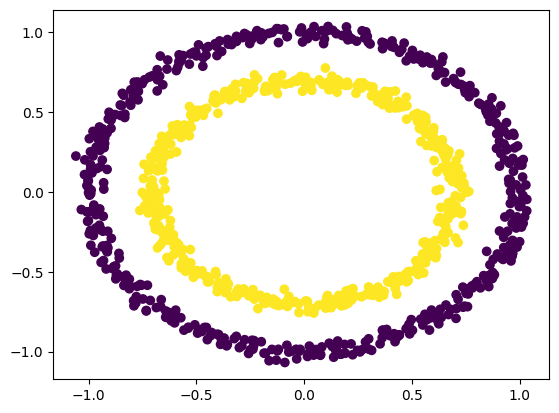

In [19]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1], 
            c=y)

### Input/Output shape

In [20]:
X.shape, y.shape

((1000, 2), (1000,))

## Splitting into train and test data

In [21]:
X = torch.from_numpy(X).type(torch.float) # NumPy array to PyTorch tensor
y = torch.from_numpy(y).type(torch.float) # NumPy stores floats as 64-bit by default, but PyTorch uses 32-bit floats by default

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, # 20 % for test and 80% for train
                                                    random_state=42) 

# Move data to GPU if available
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

len(X_train), len(X_test)

(800, 200)

# Making custom model

In [22]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(in_features=2, out_features=16),
    nn.ReLU(),
    nn.Linear(in_features=16, out_features=16),
    nn.ReLU(),
    nn.Linear(in_features=16, out_features=1)
).to(device)

## Traning model

In [23]:
def calculate_accuracy(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # `.item()` turns a scalar tensor into a regular python number
    return (correct/len(y_pred))*100

In [24]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100
for epoch in range(1, epochs+1):

    model.train()
    y_logits = model(X_train).squeeze()
    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch%10 == 0:
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test).squeeze()
            test_preds = torch.round(torch.sigmoid(test_logits))
            acc = calculate_accuracy(y_true=y_test, y_pred=test_preds)
            print(f"Epoch : {epoch} | Test Accuracy : {acc:.2f}%")

Epoch : 10 | Test Accuracy : 60.00%
Epoch : 20 | Test Accuracy : 99.50%
Epoch : 30 | Test Accuracy : 100.00%
Epoch : 40 | Test Accuracy : 100.00%
Epoch : 50 | Test Accuracy : 100.00%
Epoch : 60 | Test Accuracy : 100.00%
Epoch : 70 | Test Accuracy : 100.00%
Epoch : 80 | Test Accuracy : 100.00%
Epoch : 90 | Test Accuracy : 100.00%
Epoch : 100 | Test Accuracy : 100.00%


# Comparing custom model to TabPFN

## TabPFN predictions

In [ ]:
clf = TabPFNClassifier(device=device, random_state=42)
clf.fit(X_train.cpu(), y_train.cpu())  # Apparently, TabPFNClassifier expects CPU tensors, so we move them back to CPU before fitting (it should handle the device internally)
tabpfn_preds = clf.predict(X_test.cpu())

## Custom predictions

In [38]:
model.eval()
with torch.inference_mode():
    test_logits = model(X_test).squeeze()
    model_preds = torch.round(torch.sigmoid(test_logits))

## Comparing results

In [39]:
tabpfn_preds = torch.from_numpy(tabpfn_preds).type(torch.float).to(device)

tabpfn_acc = calculate_accuracy(y_true=y_test, y_pred=tabpfn_preds)
model_acc = calculate_accuracy(y_true=y_test, y_pred=model_preds)

print(f"TabPFN Accuracy: {tabpfn_acc:.2f}%")
print(f"Custom Model Accuracy: {model_acc:.2f}%")

TabPFN Accuracy: 100.00%
Custom Model Accuracy: 100.00%


## Conclusion

Once the API token setup was done, the actual prediction was only 3 lines of code, which is much quicker than setting up a custom model and training loop.

However, if we care about performance and speed rather than ease of use, then TabPFN might be overkill for such a simple dataset, both models achieve 100% accuracy but TabPFN takes around `1.8s` to fit, while training the custom model for 100 epochs (which is enough for 100% accuracy) only took about `0.1s`.
    
This highlights a broader issue with TabPFN : it is too generic, and might not always be the best solution for a generic problem.

# Testing on a more complicated dataset

## Getting data

In [41]:
from sklearn.metrics import roc_auc_score
import pandas as pd, io, zipfile, requests

url_zip = "https://archive.ics.uci.edu/static/public/174/parkinsons.zip"
with requests.get(url_zip) as r:
    r.raise_for_status()
    zf = zipfile.ZipFile(io.BytesIO(r.content))
    df = pd.read_csv(zf.open("parkinsons.data"))
X, y = df.drop(["status", "name"], axis=1), df["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [42]:
X_train = torch.tensor(X_train.values).type(torch.float).to(device)
X_test = torch.tensor(X_test.values).type(torch.float).to(device)
y_train = torch.tensor(y_train.values).type(torch.float).to(device)
y_test = torch.tensor(y_test.values).type(torch.float).to(device)

X_train.shape, y_train.shape

(torch.Size([156, 22]), torch.Size([156]))

## Setting up model

In [43]:
model = nn.Sequential(
    nn.Linear(in_features=22, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=1),
).to(device)

## Training model

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.01)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

for epoch in range(1, epochs+1):
    model.train()
    y_logits = model(X_train).squeeze()
    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch%100 == 0:
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test).squeeze()
        test_loss = loss_fn(test_logits, y_test)
        test_probs = torch.sigmoid(test_logits)
        roc_auc = roc_auc_score(y_test.cpu(), test_probs.cpu())
        print(f"Epoch : {epoch} | Loss : {loss:.4f} | Test Loss : {test_loss:.4f} | Roc-Auc : {roc_auc:.4f}")

Epoch : 100 | Loss : 0.5760 | Test Loss : 0.4900 | Roc-Auc : 0.5000
Epoch : 200 | Loss : 0.5760 | Test Loss : 0.4900 | Roc-Auc : 0.5000
Epoch : 300 | Loss : 0.5760 | Test Loss : 0.4900 | Roc-Auc : 0.5000
Epoch : 400 | Loss : 0.5760 | Test Loss : 0.4900 | Roc-Auc : 0.5000
Epoch : 500 | Loss : 0.5760 | Test Loss : 0.4900 | Roc-Auc : 0.5000
Epoch : 600 | Loss : 0.5760 | Test Loss : 0.4900 | Roc-Auc : 0.5000
Epoch : 700 | Loss : 0.5760 | Test Loss : 0.4900 | Roc-Auc : 0.5000
Epoch : 800 | Loss : 0.5760 | Test Loss : 0.4900 | Roc-Auc : 0.5000
Epoch : 900 | Loss : 0.5760 | Test Loss : 0.4900 | Roc-Auc : 0.5000
Epoch : 1000 | Loss : 0.5760 | Test Loss : 0.4900 | Roc-Auc : 0.5000


## Comparing results

In [47]:
clf = TabPFNClassifier(device=device, random_state=42)
clf.fit(X_train.cpu(), y_train.cpu())  # Apparently, TabPFNClassifier expects CPU tensors, so we move them back to CPU before fitting (it should handle the device internally)
tabpfn_probs = clf.predict_proba(X_test.cpu())

In [48]:
tabpfn_roc_auc = roc_auc_score(y_test.cpu(), tabpfn_probs[:, 1]) # `predict_proba` returns probabilities for both classes, we want the positive class (class 1)

model.eval()
with torch.inference_mode():
    test_logits = model(X_test).squeeze()
    model_probs = torch.sigmoid(test_logits)
model_roc_auc = roc_auc_score(y_test.cpu(), model_probs.cpu())

print(f"TabPFN ROC AUC Score: {tabpfn_roc_auc:.4f}")
print(f"Model ROC AUC Score: {model_roc_auc:.4f}")

TabPFN ROC AUC Score: 0.9777
Model ROC AUC Score: 0.5000


## Conclusion

We can see that this time, the custom model performed way worse (in fact it had a score of `0.5000` which is basically as good as guessing at random).

We could improve its performance by making the model bigger, but it already takes roughly the same about of time to train as fitting a TabPFN classifier, making it bigger would ruin its only advantage.

So for more complicated datasets TabPFN is the clear winner (as long as you're ok with their license of course).